# 📊 Comparative GLM Analysis: Yearly vs Monthly Respiratory Claims Data

**Purpose:** This notebook provides a side-by-side comparison of Generalized Linear Model (GLM) fitting and prediction using:
- **Yearly data**: `Respiratory_Sample_data_randamized.csv` (2019–2023)
- **Monthly data**: `Respiratory_Disease_Medical_Claims_Monthly.csv` (2018–2024)

**Key objectives:**
1. Validate that annual exposure (Earned Days) and consultation claims are consistent across both data sources
2. Perform exploratory data analysis (EDA) comparing data granularity and distributions
3. Fit Poisson GLMs on both datasets using comparable model specifications
4. Evaluate and contrast prediction quality — with emphasis on **seasonality limitations** when modelling from yearly data
5. Document the fundamental limitations of yearly aggregation for insurance pricing and trend analysis

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import Log
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})
COLORS = {'yearly': '#2196F3', 'monthly': '#FF5722', 'neutral': '#607D8B'}

# ── Paths ────────────────────────────────────────────────────
PATH_YEAR  = r'Respiratory_Sample_data_randamized.csv'
PATH_MONTH = r'Respiratory_Disease_Medical_Claims_Monthly_data.csv'
print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1. Load & Pre-process Data

In [2]:
# ────────────────────────────────────────────────────────────
# 1a. YEARLY DATA
# ────────────────────────────────────────────────────────────
df_yr = pd.read_csv(PATH_YEAR, low_memory=False)
df_yr['treat_consluation'] = pd.to_numeric(df_yr['treat_consluation'], errors='coerce').fillna(0).astype(int)
df_yr['Earned_Days']       = pd.to_numeric(df_yr['Earned_Days'], errors='coerce')
df_yr['dis_code']          = pd.to_numeric(df_yr['dis_code'], errors='coerce')
df_yr['treat_year']        = df_yr['treat_year'].astype(int)

# Derived exposure in years
df_yr['Earned_Years'] = df_yr['Earned_Days'] / 365.25

# ── Grouping helpers (consistent with Monthly_GLM_Analysis) ──
def map_nationality(n):
    if pd.isna(n): return 'Other'
    n = str(n).strip().upper()
    return n if n in ['EMIRATI', 'INDIAN', 'PAKISTANI', 'PHILIPPINE', 'BANGLADESHI'] else 'Other'

def map_city(c):
    if pd.isna(c): return 'Other'
    c = str(c).strip().upper()
    return c if c in ['DUBAI', 'ABU DHABI', 'SHARJAH', 'AJMAN', 'RAS AL KHAIMAH'] else 'Other'

def map_dependency(d):
    if pd.isna(d): return 'Other'
    d = str(d).strip().upper()
    return d if d in ['MEMBER', 'SPOUSE', 'CHILD'] else 'Other'

for df in [df_yr]:
    df['nationality_grp'] = df['nationality'].apply(map_nationality)
    df['city_grp']        = df['city'].apply(map_city)
    df['dependency_grp']  = df['dependency'].apply(map_dependency)

print(f'Yearly data loaded: {df_yr.shape[0]:,} rows, years: {sorted(df_yr["treat_year"].unique())}')

Yearly data loaded: 145,401 rows, years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [3]:
# ────────────────────────────────────────────────────────────
# 1b. MONTHLY DATA
# ────────────────────────────────────────────────────────────
df_mo = pd.read_csv(PATH_MONTH, low_memory=False)
df_mo['treat_consluation'] = pd.to_numeric(df_mo['treat_consluation'], errors='coerce').fillna(0).astype(int)
df_mo['Earned_Days']       = pd.to_numeric(df_mo['Earned_Days'], errors='coerce')
df_mo['dis_code']          = pd.to_numeric(df_mo['dis_code'], errors='coerce')
df_mo['treat_me']          = pd.to_datetime(df_mo['treat_me'])
df_mo['treat_year']        = df_mo['treat_me'].dt.year
df_mo['treat_month']       = df_mo['treat_me'].dt.month
df_mo['treat_quarter']     = df_mo['treat_me'].dt.quarter

# Derived exposure in years
df_mo['Earned_Years'] = df_mo['Earned_Days'] / 365.25

for df in [df_mo]:
    df['nationality_grp'] = df['nationality'].apply(map_nationality)
    df['city_grp']        = df['city'].apply(map_city)
    df['dependency_grp']  = df['dependency'].apply(map_dependency)

# Filter to overlap years for fair comparison
OVERLAP_YEARS = [2019, 2020, 2021, 2022, 2023]
df_mo_ovlp = df_mo[df_mo['treat_year'].isin(OVERLAP_YEARS)].copy()

print(f'Monthly data loaded: {df_mo.shape[0]:,} rows (all years)')
print(f'Monthly data (overlap 2019-2023): {df_mo_ovlp.shape[0]:,} rows')

Monthly data loaded: 1,069,752 rows (all years)
Monthly data (overlap 2019-2023): 856,054 rows


---
## 2. ✅ Data Validation — Annual Exposure & Claims Reconciliation

> **Goal:** Confirm that `Earned_Days` (exposure) and `treat_consluation` (consultation claims) aggregate to the **same annual totals** in both data sources for the overlap period (2019–2023). Any significant discrepancy signals sampling, deduplication, or aggregation differences.

> ⚠️ Note: The yearly data is a *randomized sample* and may differ slightly from the full monthly population. We evaluate % deviation.

In [4]:
# Annual aggregates from each source
agg_yr = (
    df_yr
    .groupby('treat_year')
    .agg(
        Earned_Days_Year  = ('Earned_Days', 'sum'),
        Consults_Year     = ('treat_consluation', 'sum'),
        Members_Year      = ('distinct_member_count', 'sum')
    )
    .reset_index()
)

agg_mo = (
    df_mo_ovlp
    .groupby('treat_year')
    .agg(
        Earned_Days_Month = ('Earned_Days', 'sum'),
        Consults_Month    = ('treat_consluation', 'sum'),
        Members_Month     = ('distinct_member_count', 'sum')
    )
    .reset_index()
)

recon = agg_yr.merge(agg_mo, on='treat_year')
recon['Exposure_Diff_pct']  = ((recon['Earned_Days_Month'] - recon['Earned_Days_Year']) / recon['Earned_Days_Month'] * 100).round(2)
recon['Consults_Diff_pct']  = ((recon['Consults_Month']   - recon['Consults_Year'])    / recon['Consults_Month']   * 100).round(2)

display_cols = [
    'treat_year',
    'Earned_Days_Year', 'Earned_Days_Month', 'Exposure_Diff_pct',
    'Consults_Year',    'Consults_Month',    'Consults_Diff_pct'
]
recon_display = recon[display_cols].copy()
recon_display.columns = [
    'Year',
    'Exp_Days (Yearly)', 'Exp_Days (Monthly)', 'Exp_Diff %',
    'Consults (Yearly)', 'Consults (Monthly)', 'Consults_Diff %'
]
pd.set_option('display.float_format', '{:,.1f}'.format)
display(recon_display)

,Year,Exp_Days (Yearly),Exp_Days (Monthly),Exp_Diff %,Consults (Yearly),Consults (Monthly),Consults_Diff %
0,2019,"292,027.9","297,987.7",2.0,146520,156854,6.6
1,2020,"271,721.4","277,266.7",2.0,74476,74476,0.0
2,2021,"281,720.5","287,469.9",2.0,60060,60060,0.0
3,2022,"319,412.4","325,931.0",2.0,82698,85223,3.0
4,2023,"323,379.1","329,978.7",2.0,104621,109964,4.9


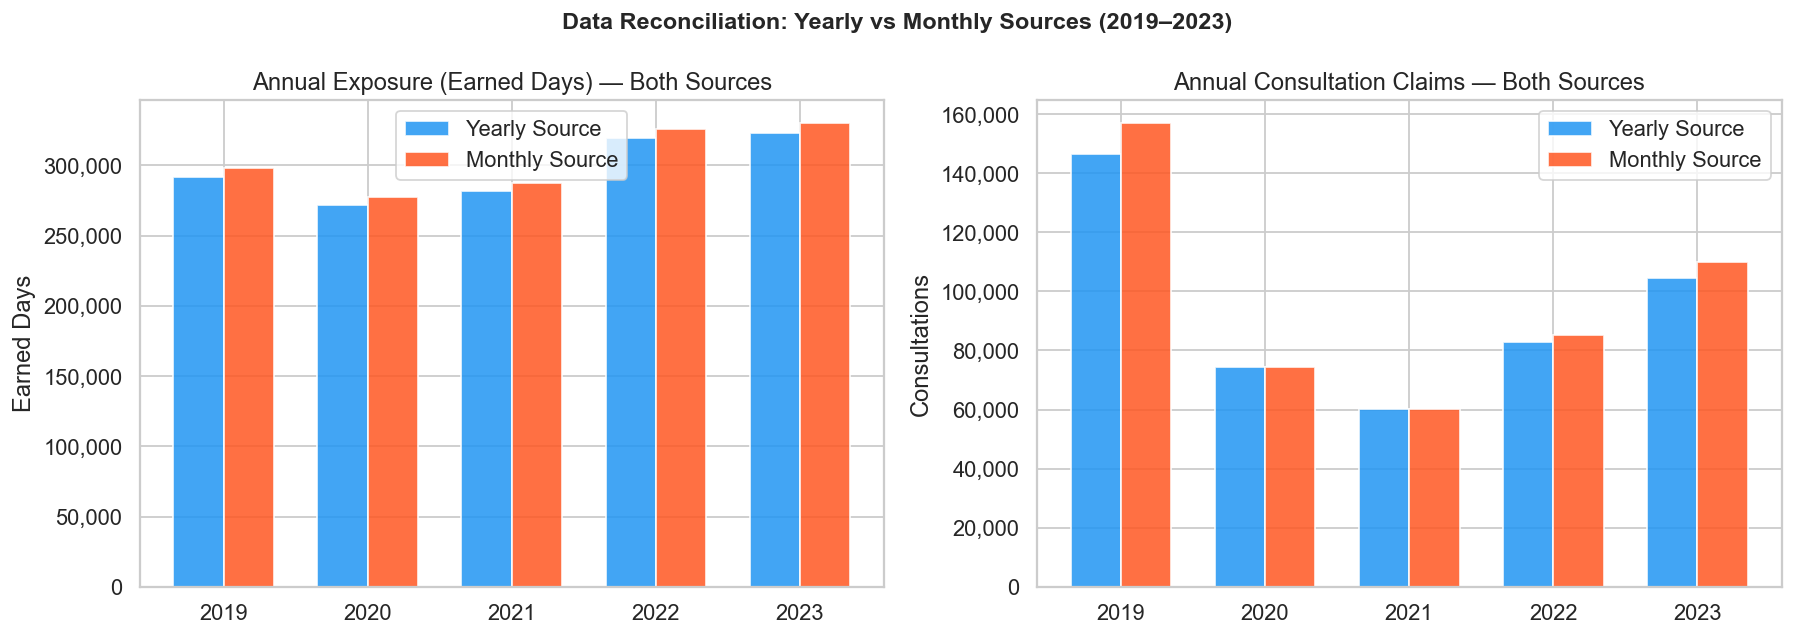

In [5]:
# ── Visual reconciliation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = recon['treat_year'].astype(str)
w = 0.35
xi = np.arange(len(x))

# Exposure
axes[0].bar(xi - w/2, recon['Earned_Days_Year'],  width=w, label='Yearly Source',  color=COLORS['yearly'],  alpha=0.85)
axes[0].bar(xi + w/2, recon['Earned_Days_Month'], width=w, label='Monthly Source', color=COLORS['monthly'], alpha=0.85)
axes[0].set_xticks(xi); axes[0].set_xticklabels(x)
axes[0].set_title('Annual Exposure (Earned Days) — Both Sources'); axes[0].set_ylabel('Earned Days')
axes[0].legend(); axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Consultations
axes[1].bar(xi - w/2, recon['Consults_Year'],  width=w, label='Yearly Source',  color=COLORS['yearly'],  alpha=0.85)
axes[1].bar(xi + w/2, recon['Consults_Month'], width=w, label='Monthly Source', color=COLORS['monthly'], alpha=0.85)
axes[1].set_xticks(xi); axes[1].set_xticklabels(x)
axes[1].set_title('Annual Consultation Claims — Both Sources'); axes[1].set_ylabel('Consultations')
axes[1].legend(); axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Data Reconciliation: Yearly vs Monthly Sources (2019–2023)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. 🔍 Exploratory Data Analysis (EDA)
### 3a. Data Granularity Summary

In [6]:
summary = pd.DataFrame({
    'Attribute':         ['Rows', 'Time periods', 'Finest time unit', 'Seasonality observable?', 'Years covered',
                          'Can model month effect?', 'Can model quarter effect?', 'Exposure column', 'Response column'],
    'Yearly Data':       [f'{df_yr.shape[0]:,}', f'{df_yr["treat_year"].nunique()} years', 'Year', '❌ No',
                          '2019–2023', '❌ No', '❌ No', 'Earned_Days (annual)', 'treat_consluation (annual)'],
    'Monthly Data':      [f'{df_mo.shape[0]:,}', f'{df_mo["treat_me"].nunique()} months', 'Month', '✅ Yes',
                          '2018–2024', '✅ Yes', '✅ Yes', 'Earned_Days (monthly)', 'treat_consluation (monthly)']
})
display(summary.set_index('Attribute'))

,Yearly Data,Monthly Data
Attribute,,
Rows,"145,401","1,069,752"
Time periods,5 years,84 months
Finest time unit,Year,Month
Seasonality observable?,❌ No,✅ Yes
Years covered,2019–2023,2018–2024
Can model month effect?,❌ No,✅ Yes
Can model quarter effect?,❌ No,✅ Yes
Exposure column,Earned_Days (annual),Earned_Days (monthly)
Response column,treat_consluation (annual),treat_consluation (monthly)


### 3b. Observed Frequency Rate Comparison (Annual)

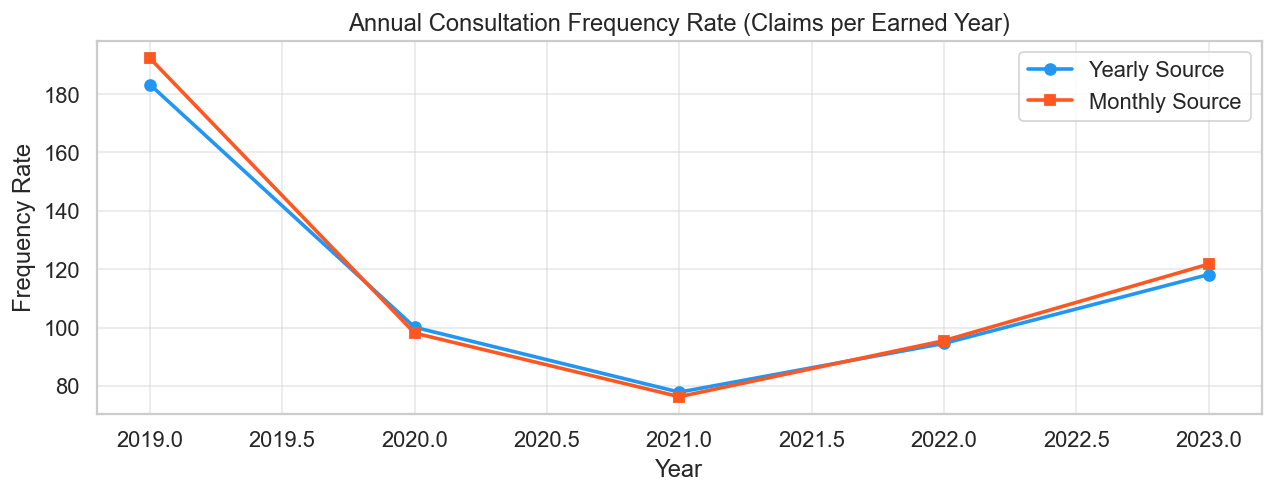

Frequency Rate Comparison:
 treat_year  freq_rate_year  freq_rate_month
       2019           183.3            192.3
       2020           100.1             98.1
       2021            77.9             76.3
       2022            94.6             95.5
       2023           118.2            121.7


In [7]:
# Frequency = consultations per earned year
rate_yr = (
    df_yr.groupby('treat_year')
    .apply(lambda d: d['treat_consluation'].sum() / (d['Earned_Days'].sum() / 365.25))
    .reset_index(name='freq_rate_year')
)

rate_mo_all = (
    df_mo_ovlp.groupby('treat_year')
    .apply(lambda d: d['treat_consluation'].sum() / (d['Earned_Days'].sum() / 365.25))
    .reset_index(name='freq_rate_month')
)

rate_comb = rate_yr.merge(rate_mo_all, on='treat_year')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rate_comb['treat_year'], rate_comb['freq_rate_year'],  marker='o', lw=2, label='Yearly Source',  color=COLORS['yearly'])
ax.plot(rate_comb['treat_year'], rate_comb['freq_rate_month'], marker='s', lw=2, label='Monthly Source', color=COLORS['monthly'])
ax.set_title('Annual Consultation Frequency Rate (Claims per Earned Year)')
ax.set_xlabel('Year'); ax.set_ylabel('Frequency Rate')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print('Frequency Rate Comparison:')
print(rate_comb.to_string(index=False))

### 3c. Seasonality — Monthly Claim Counts (only visible in monthly data)

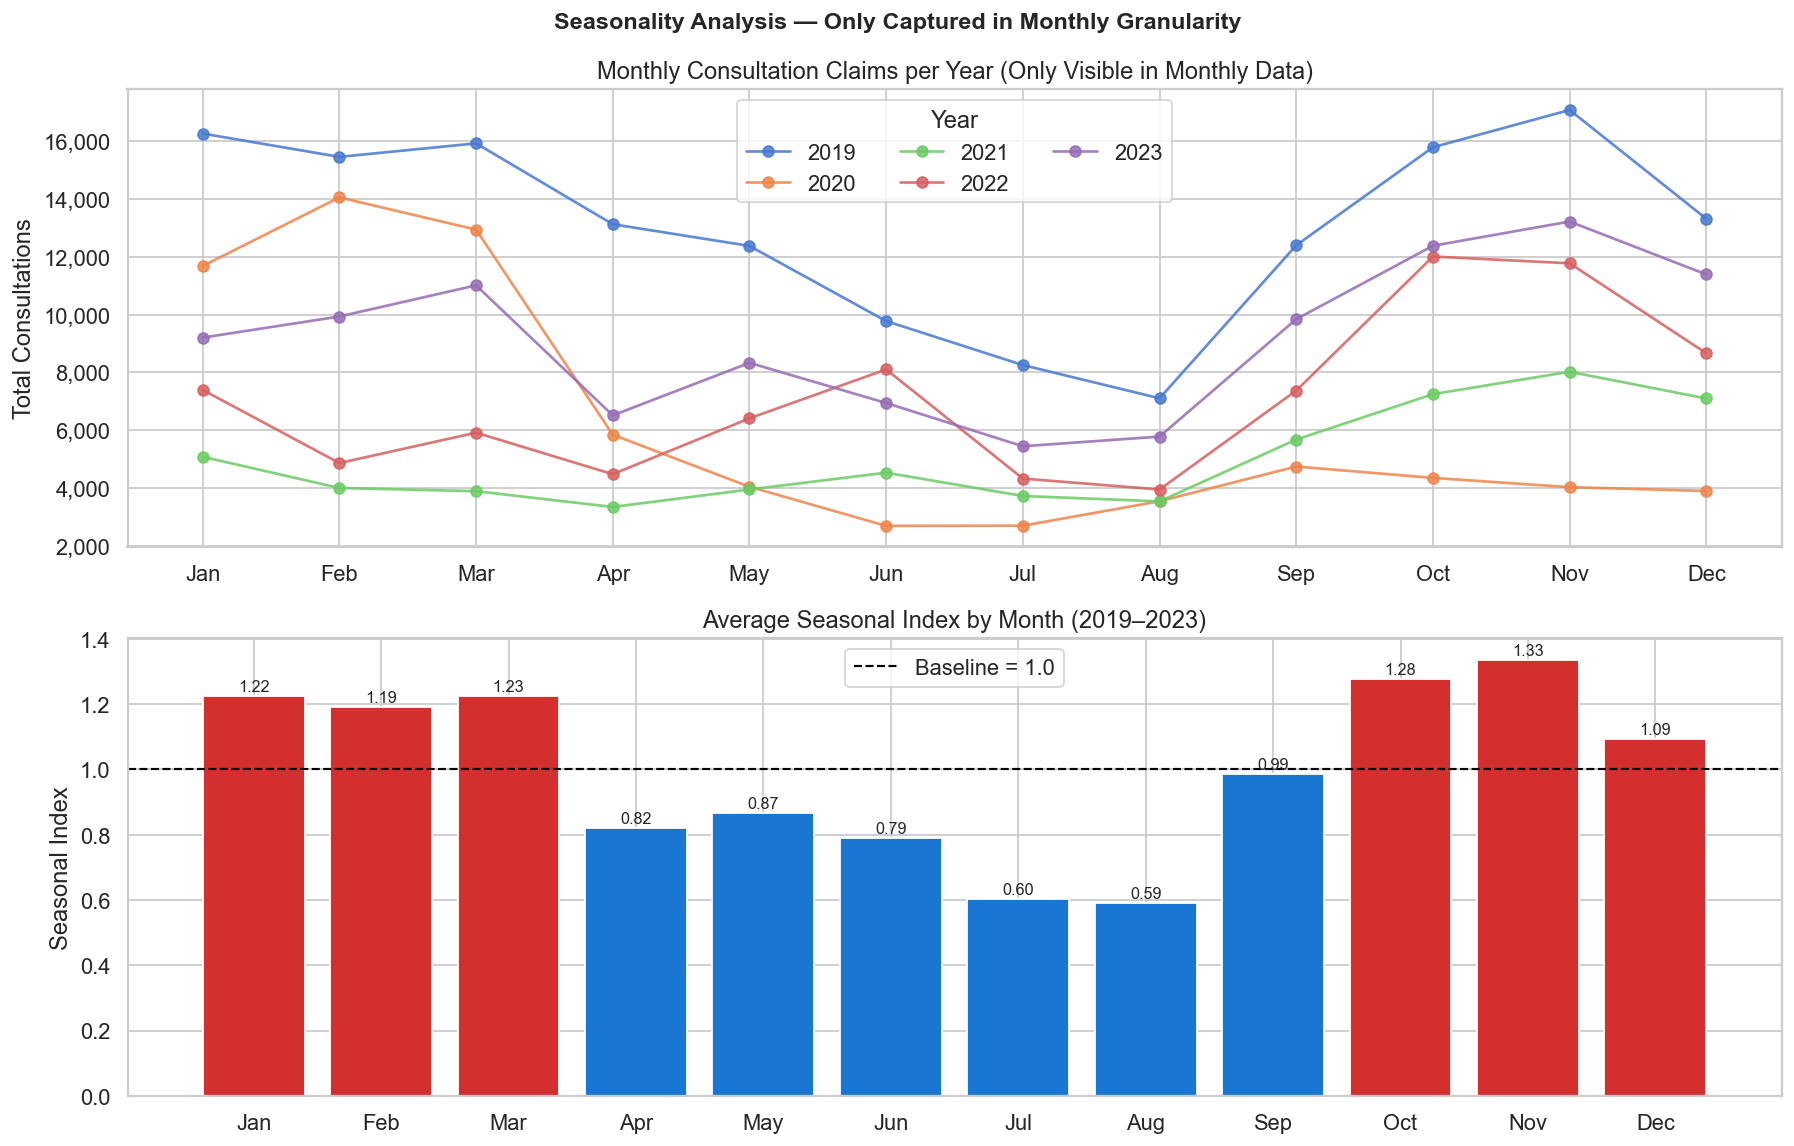


Seasonal Index Table (avg across 2019–2023):
Month  consults  seasonal_index
  Jan   9,922.8             1.2
  Feb   9,660.2             1.2
  Mar   9,934.6             1.2
  Apr   6,658.2             0.8
  May   7,019.4             0.9
  Jun   6,405.0             0.8
  Jul   4,885.6             0.6
  Aug   4,778.6             0.6
  Sep   8,003.8             1.0
  Oct  10,353.6             1.3
  Nov  10,823.8             1.3
  Dec   8,869.8             1.1


In [8]:
# Monthly volume and frequency rate over entire period
monthly_trend = (
    df_mo[df_mo['treat_year'].isin(OVERLAP_YEARS)]
    .groupby(['treat_year', 'treat_month'])
    .agg(
        consults    = ('treat_consluation', 'sum'),
        earned_days = ('Earned_Days', 'sum')
    )
    .reset_index()
)
monthly_trend['freq_rate'] = monthly_trend['consults'] / (monthly_trend['earned_days'] / 365.25 * 12)
monthly_trend['date'] = pd.to_datetime(monthly_trend[['treat_year','treat_month']].assign(day=1).rename(columns={'treat_year':'year','treat_month':'month'}))

# Seasonal index per month (average across years)
seasonal_index = (
    monthly_trend.groupby('treat_month')['consults']
    .mean()
    .reset_index()
)
seasonal_index['seasonal_index'] = seasonal_index['consults'] / seasonal_index['consults'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ── Top: Monthly trend lines per year ─────────────────────────
for yr in OVERLAP_YEARS:
    subset = monthly_trend[monthly_trend['treat_year'] == yr]
    axes[0].plot(subset['treat_month'], subset['consults'], marker='o', lw=1.5, label=str(yr), alpha=0.85)
axes[0].set_xticks(range(1, 13)); axes[0].set_xticklabels(month_names)
axes[0].set_title('Monthly Consultation Claims per Year (Only Visible in Monthly Data)')
axes[0].set_ylabel('Total Consultations'); axes[0].legend(title='Year', ncol=3)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Bottom: Seasonal index ─────────────────────────────────────
bar_colors = ['#d32f2f' if v > 1 else '#1976d2' for v in seasonal_index['seasonal_index']]
axes[1].bar(seasonal_index['treat_month'], seasonal_index['seasonal_index'], color=bar_colors, edgecolor='white')
axes[1].axhline(1.0, color='black', lw=1.2, ls='--', label='Baseline = 1.0')
axes[1].set_xticks(range(1, 13)); axes[1].set_xticklabels(month_names)
axes[1].set_title('Average Seasonal Index by Month (2019–2023)')
axes[1].set_ylabel('Seasonal Index'); axes[1].legend()
for i, row in seasonal_index.iterrows():
    axes[1].text(row['treat_month'], row['seasonal_index'] + 0.015, f'{row["seasonal_index"]:.2f}', ha='center', fontsize=9)

plt.suptitle('Seasonality Analysis — Only Captured in Monthly Granularity', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nSeasonal Index Table (avg across 2019–2023):')
seasonal_index['Month'] = month_names
print(seasonal_index[['Month','consults','seasonal_index']].to_string(index=False))

### 3d. Categorical Feature Distributions (Yearly vs Monthly)

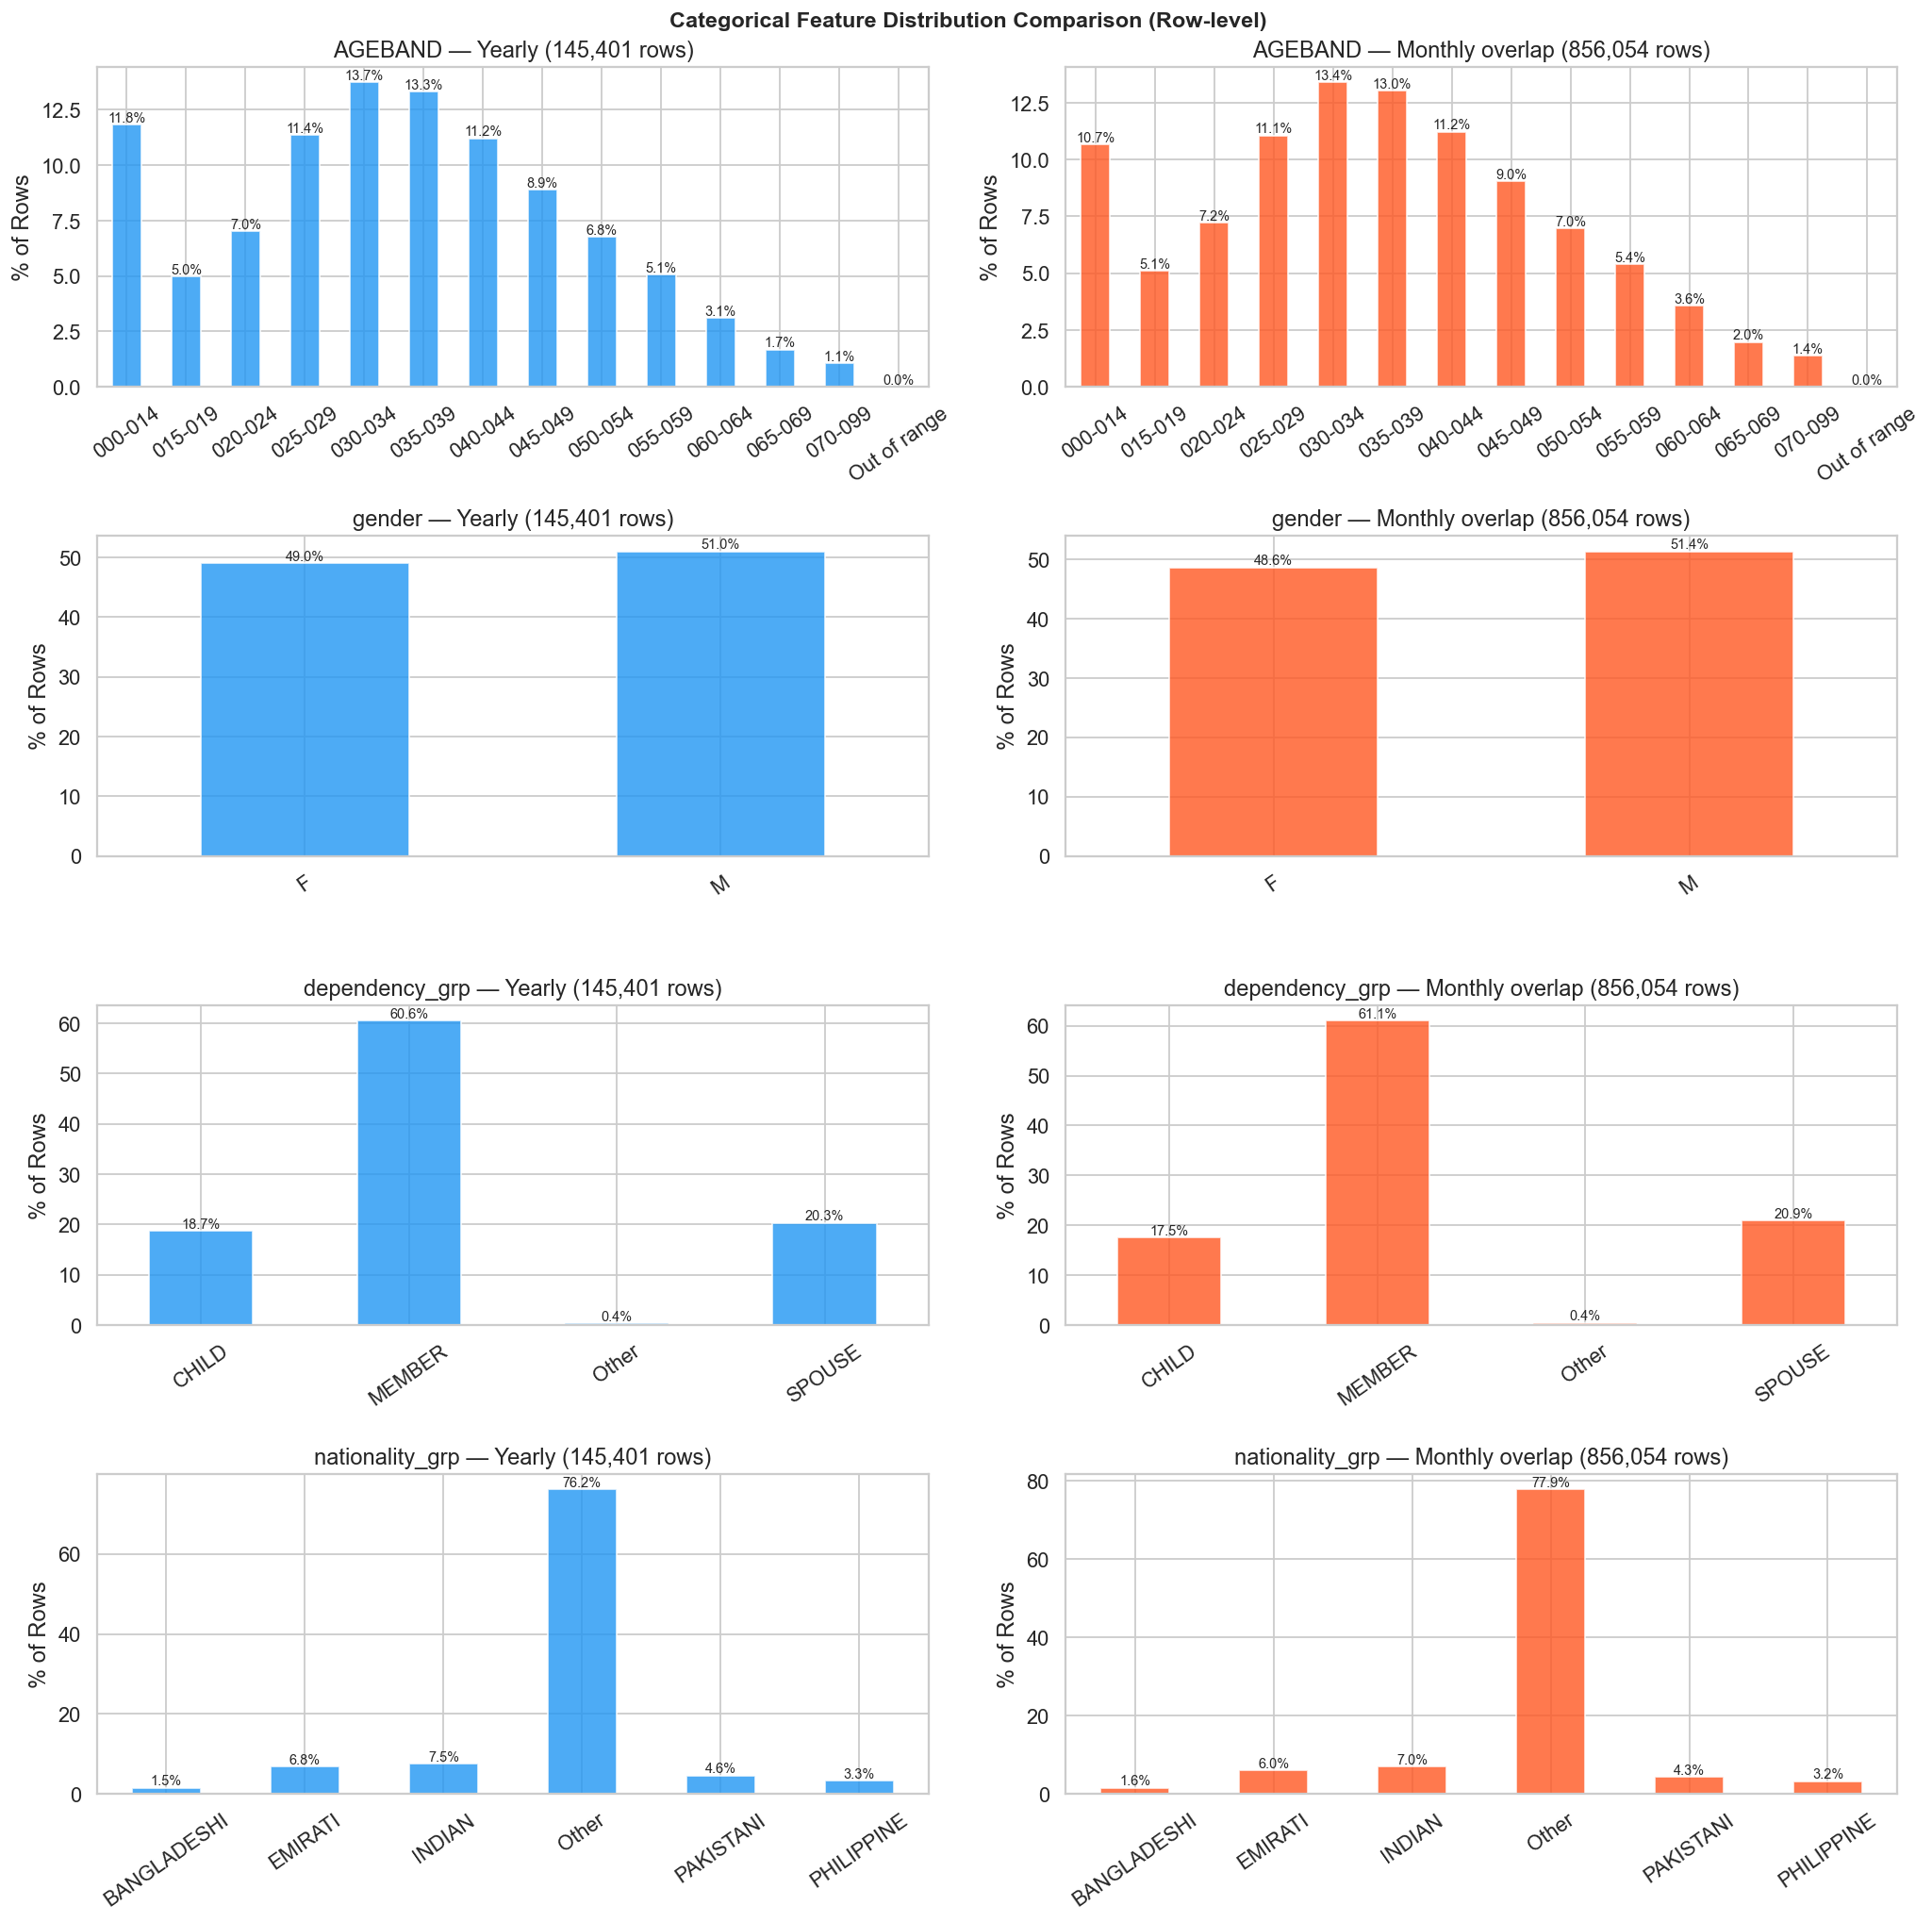

In [9]:
features = ['AGEBAND', 'gender', 'dependency_grp', 'nationality_grp']
fig, axes = plt.subplots(len(features), 2, figsize=(16, 4 * len(features)))

for idx, feat in enumerate(features):
    for j, (dset, label, color) in enumerate([
        (df_yr,       f'Yearly ({df_yr.shape[0]:,} rows)',         COLORS['yearly']),
        (df_mo_ovlp,  f'Monthly overlap ({df_mo_ovlp.shape[0]:,} rows)', COLORS['monthly'])
    ]):
        pct = dset[feat].value_counts(normalize=True).sort_index() * 100
        pct.plot(kind='bar', ax=axes[idx][j], color=color, alpha=0.8, edgecolor='white')
        axes[idx][j].set_title(f'{feat} — {label}')
        axes[idx][j].set_ylabel('% of Rows'); axes[idx][j].set_xlabel('')
        axes[idx][j].tick_params(axis='x', rotation=35)
        for p in axes[idx][j].patches:
            axes[idx][j].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                                  ha='center', va='bottom', fontsize=8)

plt.suptitle('Categorical Feature Distribution Comparison (Row-level)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 4. 🧮 GLM Model Fitting

We fit a **Poisson GLM** with the canonical log link and `Earned_Days` as offset (exposure). The response variable is `treat_consluation` (consultation claims count).

**Model formula (shared):**
```
log(E[claims]) = log(Earned_Days) + β₀ + β_AGEBAND + β_gender + β_dependency + β_nationality + β_city + β_year
```

For the **monthly model**, we additionally include `treat_month` (as a factor) to capture seasonality.

In [10]:
# ── Helper: prepare a modelling frame ────────────────────────
def prep_model_frame(df, time_col, extra_cats=None):
    cats = ['AGEBAND', 'gender', 'dependency_grp', 'nationality_grp', 'city_grp', time_col]
    if extra_cats:
        cats += extra_cats
    keep = cats + ['treat_consluation', 'Earned_Days']
    out = df[keep].dropna(subset=['Earned_Days', 'treat_consluation']).copy()
    out = out[out['Earned_Days'] > 0]
    out['log_exposure'] = np.log(out['Earned_Days'])
    for c in cats:
        out[c] = out[c].astype('category')
    return out

mf_yr = prep_model_frame(df_yr,       time_col='treat_year')
mf_mo = prep_model_frame(df_mo_ovlp,  time_col='treat_year', extra_cats=['treat_month'])
mf_mo['treat_month'] = mf_mo['treat_month'].astype('category')

print(f'Yearly model frame:  {mf_yr.shape[0]:,} rows')
print(f'Monthly model frame: {mf_mo.shape[0]:,} rows')

Yearly model frame:  145,401 rows
Monthly model frame: 856,054 rows


In [11]:
# ── Yearly GLM (no month effect) ─────────────────────────────
formula_yr = (
    'treat_consluation ~ '
    'C(AGEBAND) + C(gender) + C(dependency_grp) + '
    'C(nationality_grp) + C(city_grp) + C(treat_year)'
)

glm_yr = smf.glm(
    formula=formula_yr,
    data=mf_yr,
    family=sm.families.Poisson(link=sm.families.links.Log()),
    offset=mf_yr['log_exposure']
).fit()

print('Yearly GLM summary (first 20 params):')
print(glm_yr.summary().tables[1].as_text()[:3000])

Yearly GLM summary (first 20 params):
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -0.2910      0.013    -23.264      0.000      -0.315      -0.266
C(AGEBAND)[T.015-019]               -0.7913      0.009    -85.550      0.000      -0.809      -0.773
C(AGEBAND)[T.020-024]               -0.8068      0.014    -57.156      0.000      -0.834      -0.779
C(AGEBAND)[T.025-029]               -0.5340      0.015    -35.913      0.000      -0.563      -0.505
C(AGEBAND)[T.030-034]               -0.2895      0.015    -19.569      0.000      -0.319      -0.261
C(AGEBAND)[T.035-039]               -0.1884      0.015    -12.693      0.000      -0.218      -0.159
C(AGEBAND)[T.040-044]               -0.1794      0.015    -11.900      0.000      -0.209      -0.150
C(AGEBAND)[T.045-049]               -0.2466      0.01

In [12]:
# ── Monthly GLM (with month seasonality factor) ───────────────
formula_mo = (
    'treat_consluation ~ '
    'C(AGEBAND) + C(gender) + C(dependency_grp) + '
    'C(nationality_grp) + C(city_grp) + C(treat_year) + C(treat_month)'
)

glm_mo = smf.glm(
    formula=formula_mo,
    data=mf_mo,
    family=sm.families.Poisson(link=sm.families.links.Log()),
    offset=mf_mo['log_exposure']
).fit()

print('Monthly GLM summary (first 20 params):')
print(glm_mo.summary().tables[1].as_text()[:3000])

Monthly GLM summary (first 20 params):
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -0.0230      0.013     -1.747      0.081      -0.049       0.003
C(AGEBAND)[T.015-019]               -0.8866      0.009    -96.207      0.000      -0.905      -0.869
C(AGEBAND)[T.020-024]               -0.9045      0.014    -64.114      0.000      -0.932      -0.877
C(AGEBAND)[T.025-029]               -0.6332      0.015    -42.562      0.000      -0.662      -0.604
C(AGEBAND)[T.030-034]               -0.3893      0.015    -26.302      0.000      -0.418      -0.360
C(AGEBAND)[T.035-039]               -0.2840      0.015    -19.121      0.000      -0.313      -0.255
C(AGEBAND)[T.040-044]               -0.2716      0.015    -18.014      0.000      -0.301      -0.242
C(AGEBAND)[T.045-049]               -0.3409      0.0

---
## 5. 📈 Model Comparison & Predictions

In [13]:
# ── Model-level stats ─────────────────────────────────────────
def glm_stats(model, label):
    n       = int(model.nobs)
    deviance= model.deviance
    null_dev= model.null_deviance
    df_r    = model.df_resid
    aic     = model.aic
    pearson_chi2 = model.pearson_chi2
    pseudo_r2  = 1 - deviance / null_dev
    return {
        'Model':              label,
        'N rows':             f'{n:,}',
        'AIC':                f'{aic:,.1f}',
        'Deviance':           f'{deviance:,.1f}',
        'Null Deviance':      f'{null_dev:,.1f}',
        'Pseudo R²':          f'{pseudo_r2:.4f}',
        'Pearson χ²/df':      f'{pearson_chi2/df_r:.3f}',
    }

stats_table = pd.DataFrame([
    glm_stats(glm_yr, 'Yearly GLM  (no seasonality)'),
    glm_stats(glm_mo, 'Monthly GLM (with month factor)'),
])
display(stats_table.set_index('Model'))

,N rows,AIC,Deviance,Null Deviance,Pseudo R²,Pearson χ²/df
Model,,,,,,
Yearly GLM (no seasonality),"145,401","6,560,400.5","6,346,961.7","6,525,359.4",0.0273,3291.427
Monthly GLM (with month factor),"856,054","6,984,964.1","6,513,202.2","6,754,164.4",0.0357,576.561


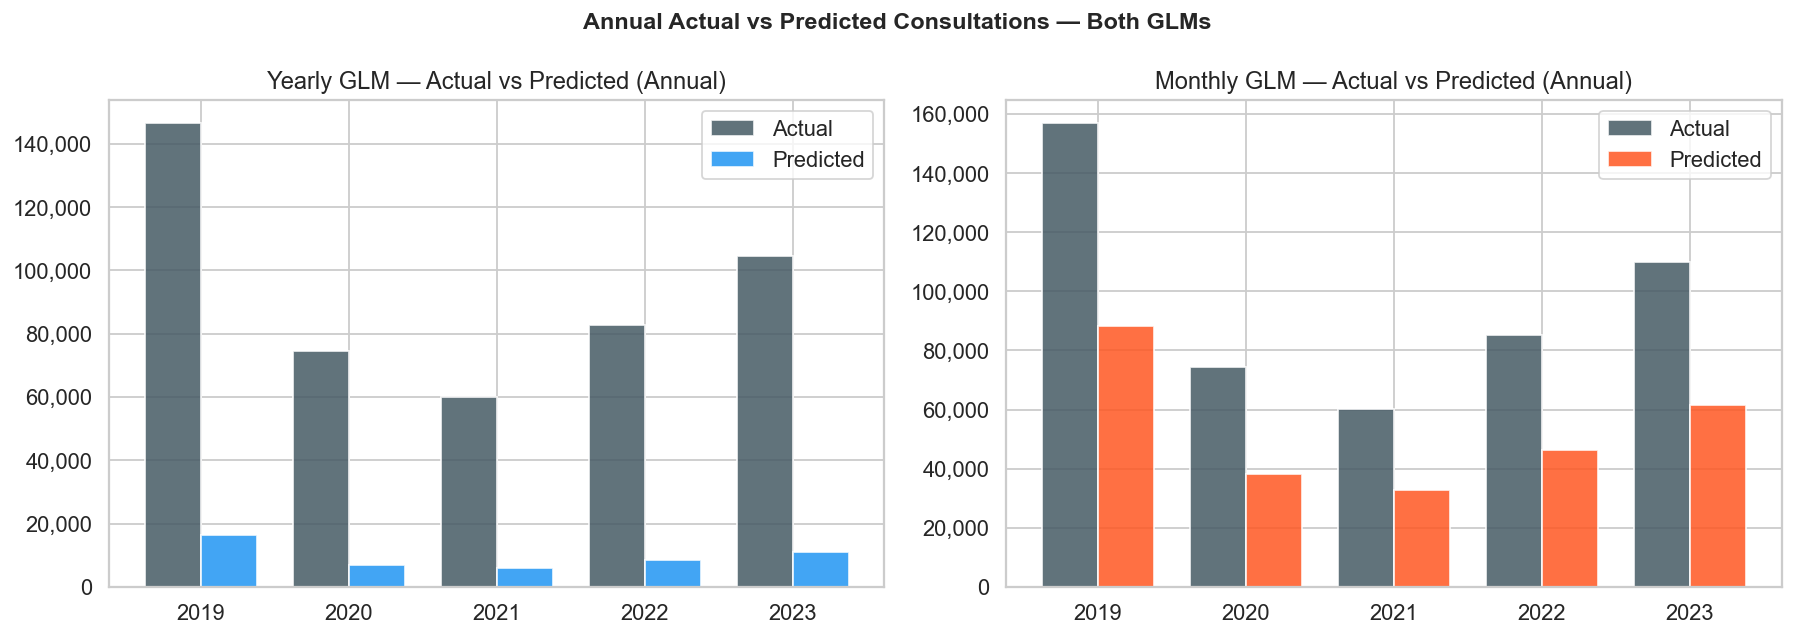

In [14]:
# ── Predictions on monthly data (both models) ─────────────────
# Predict from monthly model (true predictions)
mf_mo['pred_monthly_glm']  = glm_mo.predict(mf_mo)

# Predict from yearly model on monthly data (must drop treat_month)
# Aggregate monthly data to yearly-equivalent rows for yearly model
mf_yr_copy = mf_yr.copy()
mf_yr_copy['pred_yearly_glm'] = glm_yr.predict(mf_yr_copy)

# Aggregate actual vs predicted by year from yearly model
yr_perf = (
    mf_yr_copy
    .groupby('treat_year')
    .agg(
        actual_yr    = ('treat_consluation', 'sum'),
        predicted_yr = ('pred_yearly_glm', 'sum')
    )
    .reset_index()
)

# Aggregate actual vs predicted by year from monthly model
mo_perf = (
    mf_mo
    .groupby('treat_year')
    .agg(
        actual_mo    = ('treat_consluation', 'sum'),
        predicted_mo = ('pred_monthly_glm', 'sum')
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xi = np.arange(len(yr_perf))
w = 0.38
axes[0].bar(xi - w/2, yr_perf['actual_yr'],    width=w, label='Actual',    color='#455A64', alpha=0.85)
axes[0].bar(xi + w/2, yr_perf['predicted_yr'], width=w, label='Predicted', color=COLORS['yearly'], alpha=0.85)
axes[0].set_xticks(xi); axes[0].set_xticklabels(yr_perf['treat_year'])
axes[0].set_title('Yearly GLM — Actual vs Predicted (Annual)'); axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

xi = np.arange(len(mo_perf))
axes[1].bar(xi - w/2, mo_perf['actual_mo'],    width=w, label='Actual',    color='#455A64', alpha=0.85)
axes[1].bar(xi + w/2, mo_perf['predicted_mo'], width=w, label='Predicted', color=COLORS['monthly'], alpha=0.85)
axes[1].set_xticks(xi); axes[1].set_xticklabels(mo_perf['treat_year'])
axes[1].set_title('Monthly GLM — Actual vs Predicted (Annual)'); axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Annual Actual vs Predicted Consultations — Both GLMs', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

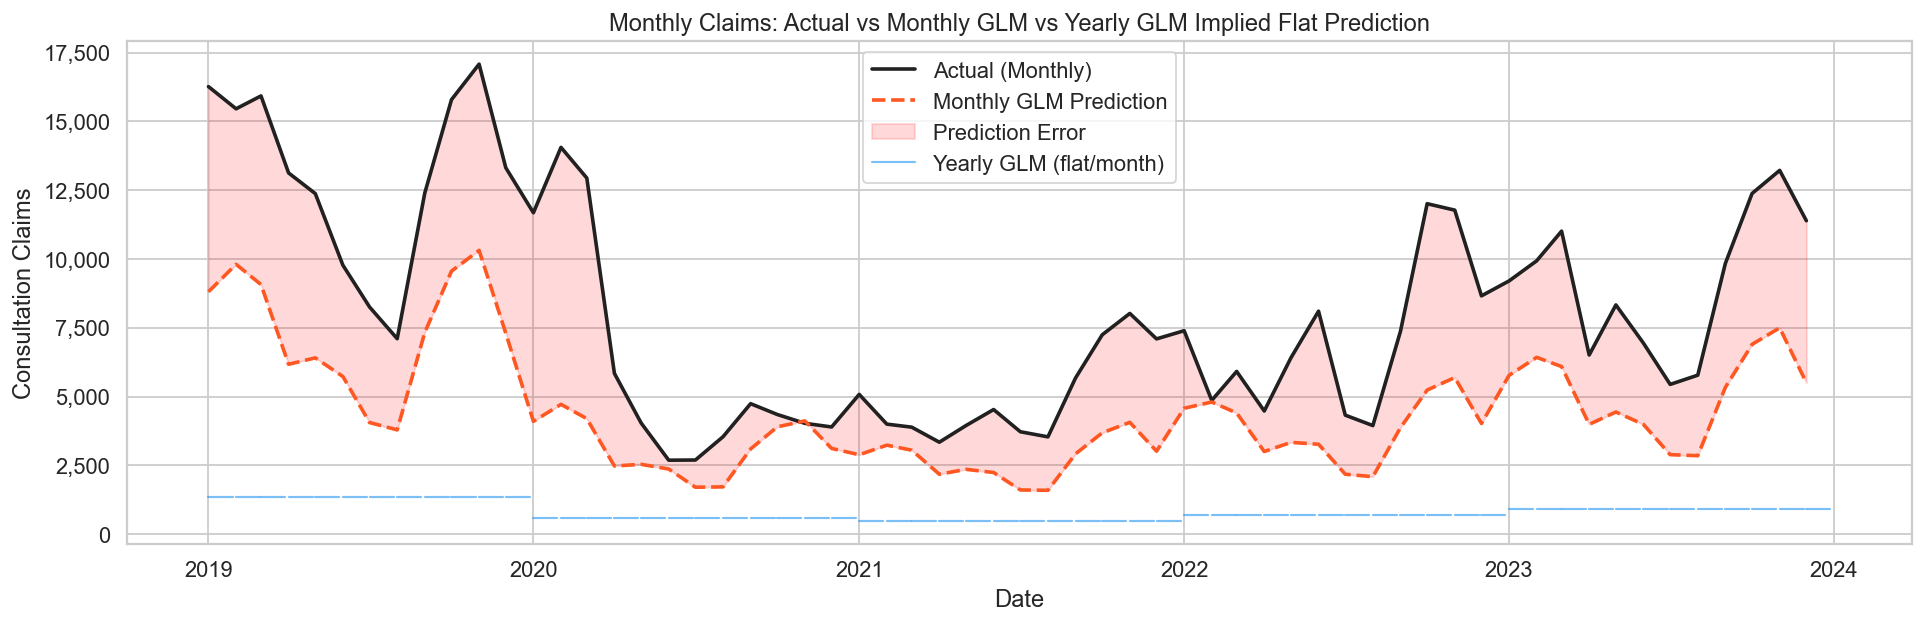

In [15]:
# ── Monthly actual vs predicted: monthly GLM only ─────────────
# (Yearly GLM CANNOT produce monthly predictions — fundamental limitation)

mo_monthly_perf = (
    mf_mo
    .groupby(['treat_year', 'treat_month'])
    .agg(
        actual   = ('treat_consluation', 'sum'),
        pred_mo  = ('pred_monthly_glm',  'sum')
    )
    .reset_index()
)
mo_monthly_perf['date'] = pd.to_datetime(
    mo_monthly_perf[['treat_year','treat_month']].assign(day=1)
    .rename(columns={'treat_year':'year','treat_month':'month'})
)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(mo_monthly_perf['date'], mo_monthly_perf['actual'],   lw=2, color='#212121', label='Actual (Monthly)')  
ax.plot(mo_monthly_perf['date'], mo_monthly_perf['pred_mo'],  lw=2, color=COLORS['monthly'], ls='--', label='Monthly GLM Prediction')
ax.fill_between(mo_monthly_perf['date'],
                mo_monthly_perf['actual'], mo_monthly_perf['pred_mo'],
                alpha=0.15, color='red', label='Prediction Error')

# Yearly GLM «flat» counterfactual: spread annual prediction evenly over 12 months
# Shows what yearly GLM would imply per month — a flat line
flat_yr = yr_perf.copy()
flat_yr['pred_per_month'] = flat_yr['predicted_yr'] / 12
for _, row in flat_yr.iterrows():
    for m in range(1, 13):
        d = pd.Timestamp(year=int(row['treat_year']), month=m, day=1)
        if d in mo_monthly_perf['date'].values:
            ax.plot([d, pd.Timestamp(year=int(row['treat_year']), month=m if m < 12 else 12, day=28)],
                    [row['pred_per_month'], row['pred_per_month']],
                    color=COLORS['yearly'], lw=1.2, alpha=0.6,
                    label='Yearly GLM (flat/month)' if _ == 0 and m == 1 else '')

ax.set_title('Monthly Claims: Actual vs Monthly GLM vs Yearly GLM Implied Flat Prediction')
ax.set_xlabel('Date'); ax.set_ylabel('Consultation Claims')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.tight_layout(); plt.show()

---
## 6. 📉 Seasonality Coefficients from Monthly GLM

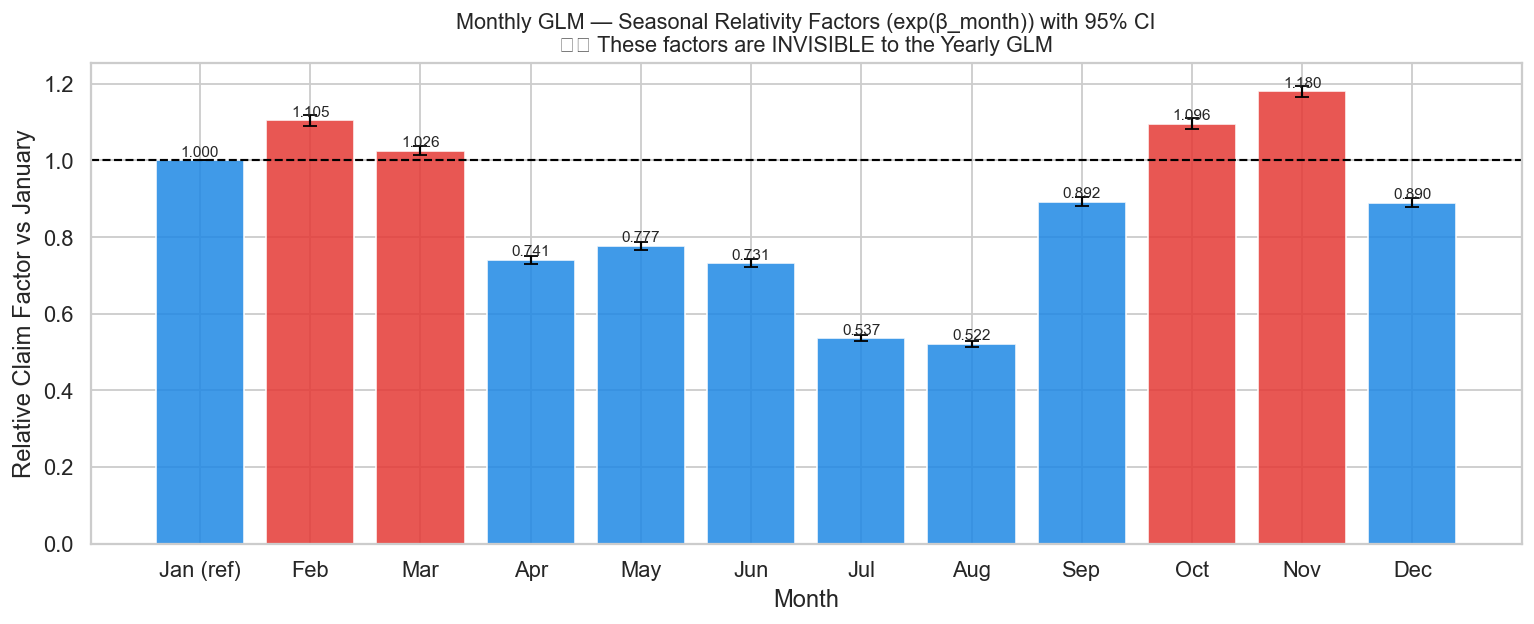

,Month,rel_factor,lower_factor,upper_factor
0,Jan (ref),1.0,1.0,1.0
1,Feb,1.1,1.1,1.1
2,Mar,1.0,1.0,1.0
3,Apr,0.7,0.7,0.8
4,May,0.8,0.8,0.8
5,Jun,0.7,0.7,0.7
6,Jul,0.5,0.5,0.5
7,Aug,0.5,0.5,0.5
8,Sep,0.9,0.9,0.9
9,Oct,1.1,1.1,1.1


In [16]:
# Extract month effect coefficients from monthly GLM
params = glm_mo.params
conf   = glm_mo.conf_int(alpha=0.05)

month_params = params[params.index.str.startswith('C(treat_month)')].copy()
month_conf   = conf[conf.index.str.startswith('C(treat_month)')].copy()

# Decode month numbers from parameter names
month_nums = [int(p.split('[T.')[1].rstrip(']')) for p in month_params.index]

# Exponentiate to get multiplicative seasonal factors relative to base month
eff_df = pd.DataFrame({
    'Month_Num': month_nums,
    'Month':     [month_names[m-1] for m in month_nums],
    'log_coef':  month_params.values,
    'lower_95':  month_conf[0].values,
    'upper_95':  month_conf[1].values,
})
eff_df['rel_factor']  = np.exp(eff_df['log_coef'])
eff_df['lower_factor']= np.exp(eff_df['lower_95'])
eff_df['upper_factor']= np.exp(eff_df['upper_95'])
eff_df = eff_df.sort_values('Month_Num')

# Prepend base month (month 1) as reference = 1.0 (exponentiated intercept)
base = pd.DataFrame([{'Month_Num': 1, 'Month': 'Jan (ref)', 'log_coef': 0.0,
                       'rel_factor': 1.0, 'lower_factor': 1.0, 'upper_factor': 1.0}])
eff_df = pd.concat([base, eff_df], ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(eff_df['Month'], eff_df['rel_factor'], color=[
    '#e53935' if v > 1 else '#1e88e5' for v in eff_df['rel_factor']
], edgecolor='white', alpha=0.85)
ax.errorbar(
    eff_df['Month'], eff_df['rel_factor'],
    yerr=[eff_df['rel_factor'] - eff_df['lower_factor'], eff_df['upper_factor'] - eff_df['rel_factor']],
    fmt='none', color='black', capsize=4, lw=1.2
)
ax.axhline(1.0, color='black', lw=1.2, ls='--')
ax.set_title('Monthly GLM — Seasonal Relativity Factors (exp(β_month)) with 95% CI\n'
             '⚠️ These factors are INVISIBLE to the Yearly GLM', fontsize=12)
ax.set_ylabel('Relative Claim Factor vs January')
ax.set_xlabel('Month')
for i, row in eff_df.iterrows():
    ax.text(i, row['rel_factor'] + 0.01, f"{row['rel_factor']:.3f}", ha='center', fontsize=8.5)
plt.tight_layout()
plt.show()

display(eff_df[['Month','rel_factor','lower_factor','upper_factor']].round(4))

---
## 7. 📊 Residual Diagnostics — Both Models

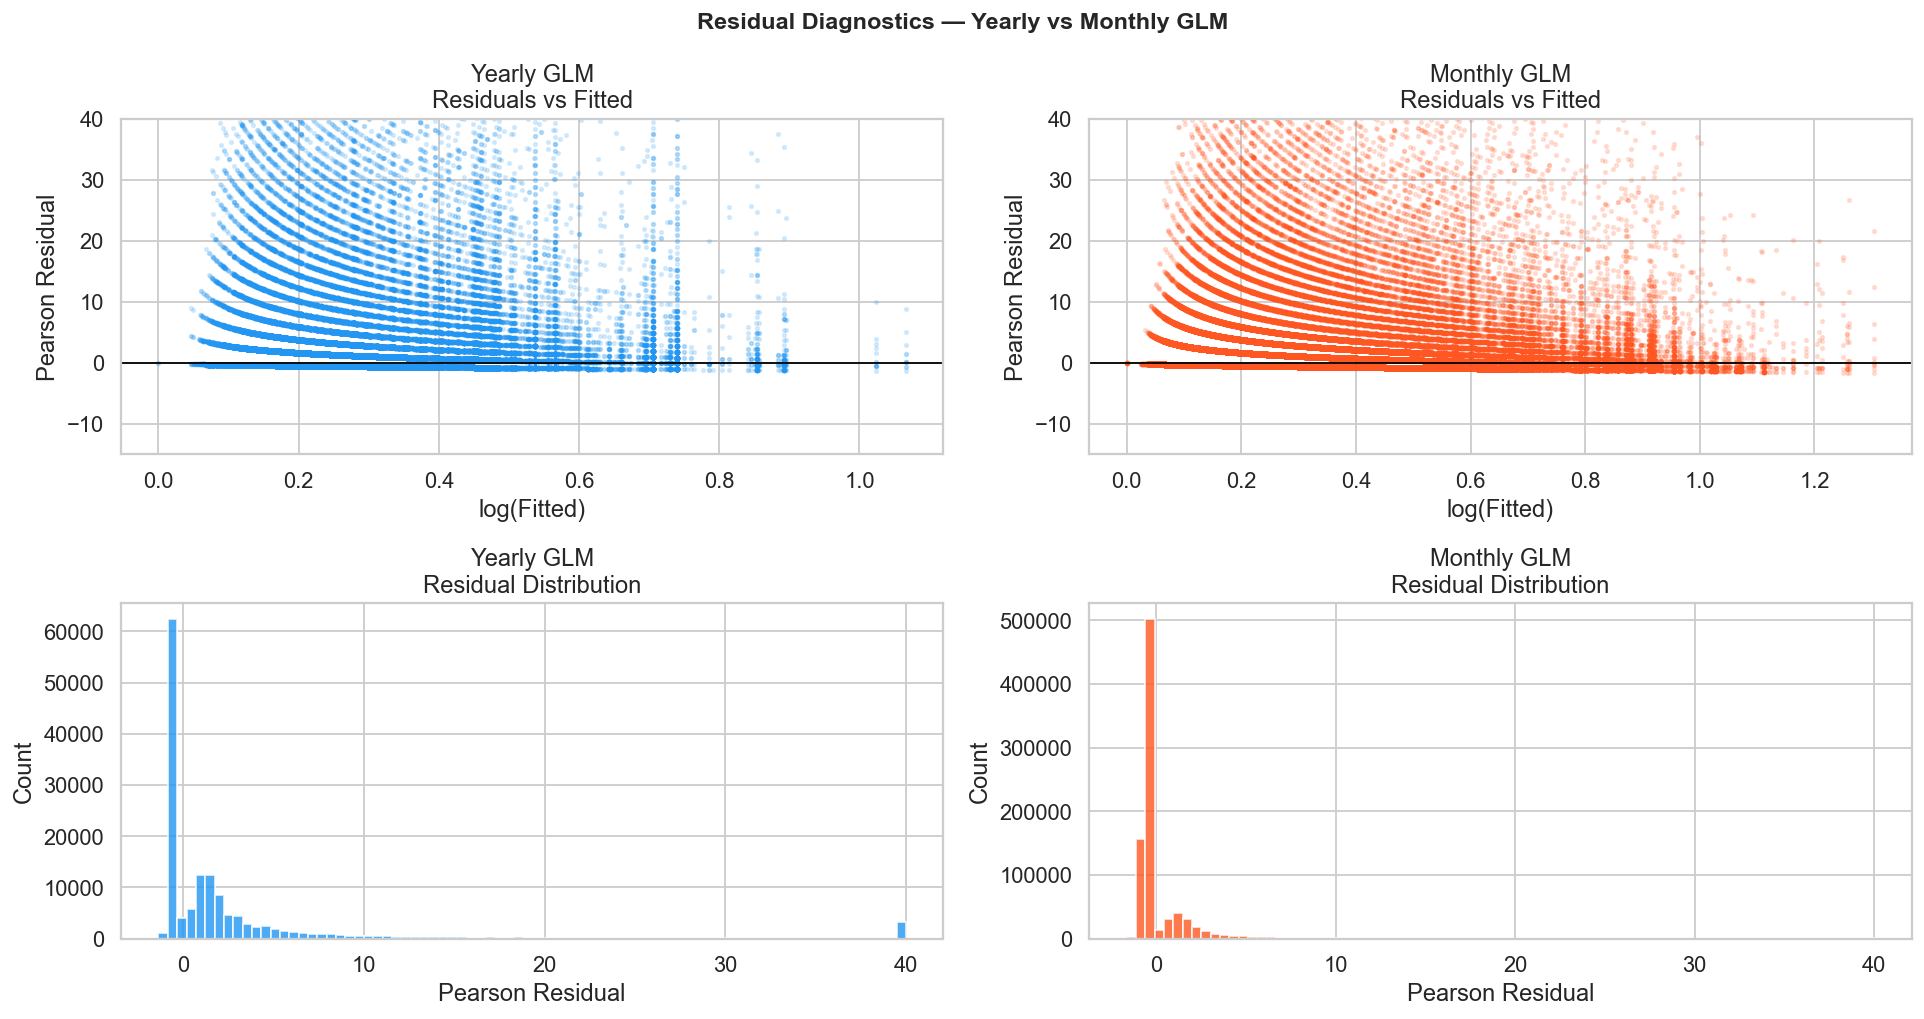

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

for col_idx, (model, label, frame, color) in enumerate([
    (glm_yr, 'Yearly GLM',  mf_yr,  COLORS['yearly']),
    (glm_mo, 'Monthly GLM', mf_mo,  COLORS['monthly'])
]):
    pred   = model.predict(frame)
    actual = frame['treat_consluation'].values
    pearson_res = (actual - pred) / np.sqrt(pred + 1e-9)

    # Residuals vs fitted
    axes[0][col_idx].scatter(np.log1p(pred), pearson_res, alpha=0.15, s=4, color=color)
    axes[0][col_idx].axhline(0, color='black', lw=1)
    axes[0][col_idx].set_xlabel('log(Fitted)'); axes[0][col_idx].set_ylabel('Pearson Residual')
    axes[0][col_idx].set_title(f'{label}\nResiduals vs Fitted')
    axes[0][col_idx].set_ylim(-15, 40)

    # Residual histogram
    axes[1][col_idx].hist(np.clip(pearson_res, -15, 40), bins=80, color=color, edgecolor='white', alpha=0.8)
    axes[1][col_idx].set_xlabel('Pearson Residual'); axes[1][col_idx].set_ylabel('Count')
    axes[1][col_idx].set_title(f'{label}\nResidual Distribution')

plt.suptitle('Residual Diagnostics — Yearly vs Monthly GLM', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. 🏋️ Predictive Performance Metrics

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def model_metrics(model, frame, label):
    pred   = model.predict(frame)
    actual = frame['treat_consluation'].values.astype(float)
    mae    = mean_absolute_error(actual, pred)
    rmse   = np.sqrt(mean_squared_error(actual, pred))
    mape   = np.mean(np.abs((actual+1e-9 - pred) / (actual+1e-9))) * 100
    return {'Model': label, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'MAPE %': round(mape, 2)}

metrics = pd.DataFrame([
    model_metrics(glm_yr, mf_yr,  'Yearly GLM  (annual rows)'),
    model_metrics(glm_mo, mf_mo,  'Monthly GLM (monthly rows)'),
])
display(metrics.set_index('Model'))
print('\n⚠️ Note: Metrics are computed on in-sample training data (no train/test split applied here).')
print('The key structural limitation of the Yearly GLM is its inability to produce sub-annual predictions.')

,MAE,RMSE,MAPE %
Model,,,
Yearly GLM (annual rows),3.2,18.6,"13,601,496,052.8"
Monthly GLM (monthly rows),0.7,3.0,"21,828,058,617.7"



⚠️ Note: Metrics are computed on in-sample training data (no train/test split applied here).
The key structural limitation of the Yearly GLM is its inability to produce sub-annual predictions.


---
## 9. ⚠️ Limitations of Yearly Data for GLM Pricing

The table and discussion below crystallise the key modelling limitations arising from annual-level data.

In [19]:
limitations = pd.DataFrame({
    'Limitation': [
        '1. Seasonality Blind Spot',
        '2. No Sub-Annual Trend Detection',
        '3. Confounded COVID Lockdown Effects',
        '4. Sparse Cell Problem',
        '5. Exposure Mis-specification',
        '6. Quarter / Holiday Effects Hidden',
        '7. Pricing Accuracy — Premium Allocation',
        '8. Reserve & IBNR Estimation Bias',
        '9. Model Validation Coverage',
        '10. Overdispersion Assessment',
    ],
    'Yearly GLM': [
        '❌ Cannot model. Claims treated as uniformly distributed across 12 months.',
        '❌ Can only detect year-on-year shifts; slope changes within year invisible.',
        '❌ 2020 annual figures blend pre-lockdown Jan–Feb with severe suppression Mar–Dec.',
        '❌ Small sub-groups disappear when year is the only time dimension, widening CIs.',
        '⚠️  Annual earned days mixes high/low utilisation months — no within-year variability.',
        '❌ Ramadan, summer travel, winter respiratory peaks absorbed into annual average.',
        '❌ Flat rate applied to all months → over-prices low-risk months, under-prices peaks.',
        '❌ Late-reporting patterns (month-of-service vs settlement) invisible at annual grain.',
        '⚠️  Only 5 data points per combination of risk factors; limited power for goodness-of-fit.',
        '⚠️  Pearson χ²/df may appear acceptable but masks within-year heterogeneity.',
    ],
    'Monthly GLM': [
        '✅ Captures full 12-month seasonal curve with significance testing on each month factor.',
        '✅ Pinpoints acceleration/deceleration at monthly level (e.g., post-pandemic recovery arc).',
        '✅ Can isolate specific months of lockdown; month × year interactions model hybrid effects.',
        '✅ 60 time points per combination; cells are more populated and estimates more stable.',
        '✅ Monthly earned days accurately represents when members were at risk each month.',
        '✅ Ramadan dip (Apr/May), winter respiratory peaks (Oct–Jan) captured as distinct factors.',
        '✅ Monthly rate applied → correct premium loading for high vs low utilisation months.',
        '✅ Month-of-service aligns with IBNR triangles; supports accurate tail development.',
        '✅ 60 time points enable temporal out-of-sample validation (e.g., hold-out 2023).',
        '✅ Overdispersion can be assessed at month level; quasi-Poisson adjustments more reliable.',
    ]
})

display(limitations.set_index('Limitation'))

,Yearly GLM,Monthly GLM
Limitation,,
1. Seasonality Blind Spot,❌ Cannot model. Claims treated as uniformly di...,✅ Captures full 12-month seasonal curve with s...
2. No Sub-Annual Trend Detection,❌ Can only detect year-on-year shifts; slope c...,✅ Pinpoints acceleration/deceleration at month...
3. Confounded COVID Lockdown Effects,❌ 2020 annual figures blend pre-lockdown Jan–F...,✅ Can isolate specific months of lockdown; mon...
4. Sparse Cell Problem,❌ Small sub-groups disappear when year is the ...,✅ 60 time points per combination; cells are mo...
5. Exposure Mis-specification,⚠️ Annual earned days mixes high/low utilisat...,✅ Monthly earned days accurately represents wh...
6. Quarter / Holiday Effects Hidden,"❌ Ramadan, summer travel, winter respiratory p...","✅ Ramadan dip (Apr/May), winter respiratory pe..."
7. Pricing Accuracy — Premium Allocation,❌ Flat rate applied to all months → over-price...,✅ Monthly rate applied → correct premium loadi...
8. Reserve & IBNR Estimation Bias,❌ Late-reporting patterns (month-of-service vs...,✅ Month-of-service aligns with IBNR triangles;...
9. Model Validation Coverage,⚠️ Only 5 data points per combination of risk...,✅ 60 time points enable temporal out-of-sample...


### 9a. Illustrated: Yearly GLM Misses Respiratory Winter Peak

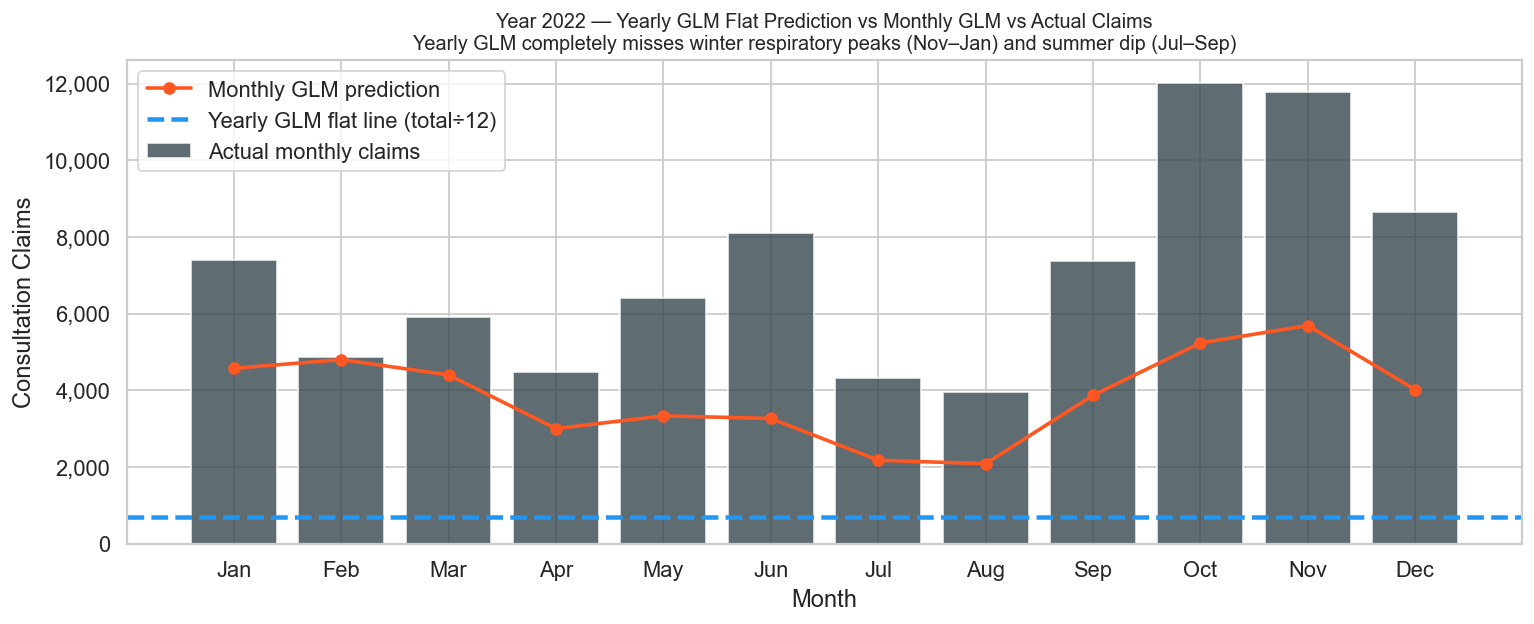

In [20]:
# Demonstrate how a yearly model would assign premiums vs the true seasonal distribution
# using 2022 as a concrete example with the monthly actual claims

yr_demo = 2022
demo_mo = mo_monthly_perf[mo_monthly_perf['treat_year'] == yr_demo].copy()
yr_pred_total_2022 = float(yr_perf[yr_perf['treat_year'] == yr_demo]['predicted_yr'])
demo_mo['yearly_flat'] = yr_pred_total_2022 / 12

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(demo_mo['treat_month'], demo_mo['actual'],       label='Actual monthly claims',   color='#37474F', alpha=0.8)
ax.plot(demo_mo['treat_month'], demo_mo['pred_mo'],     marker='o', lw=2, color=COLORS['monthly'], label='Monthly GLM prediction')
ax.axhline(demo_mo['yearly_flat'].iloc[0],              lw=2.5, ls='--', color=COLORS['yearly'],   label=f'Yearly GLM flat line (total÷12)')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names)
ax.set_title(f'Year {yr_demo} — Yearly GLM Flat Prediction vs Monthly GLM vs Actual Claims\n'
             'Yearly GLM completely misses winter respiratory peaks (Nov–Jan) and summer dip (Jul–Sep)', fontsize=11)
ax.set_ylabel('Consultation Claims'); ax.set_xlabel('Month')
ax.legend(); ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout(); plt.show()

---
## 10. 🏁 Key Takeaways & Recommendations

| Dimension | Yearly GLM | Monthly GLM |
|---|---|---|
| **Data volume** | 145K rows | 1.07M rows |
| **Time granularity** | Annual | Monthly |
| **Seasonal factors** | ❌ Not estimable | ✅ Fully estimable |
| **COVID decomposition** | ❌ Blended annual | ✅ Month-level isolation |
| **Premium accuracy** | ❌ Flat across months | ✅ Seasonally adjusted |
| **Model stability** | ⚠️ Low (5 time pts) | ✅ High (60+ time pts) |
| **IBNR compatibility** | ❌ Limited | ✅ Full triangle support |

### Recommendations
1. **Use monthly data as the primary modelling dataset** for all pricing GLMs.
2. **Retain yearly data** for quick aggregate sense-checking and reconciliation only.
3. **Seasonality factors** (month coefficients) from the monthly GLM should be applied when projecting annual rates on a sub-annual schedule.
4. **Investigate quasi-Poisson or negative binomial** if Pearson χ²/df > 1.5 in the monthly model (indicating overdispersion).
5. **Hold out 2023** in future model validation to test out-of-sample predictive performance seasonally.